In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import Adam
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer.autoguide.initialization import init_to_feasible

# ----------------------------
# 0) Robust defaults (CPU first)
# ----------------------------
device = torch.device("cpu")  # switch to "cuda" later once it runs
torch.set_default_dtype(torch.float32)
pyro.set_rng_seed(0)
torch.manual_seed(0)

# ----------------------------
# 1) Synthetic 1D data
# ----------------------------
n = 300
x = torch.linspace(-3, 3, n, device=device).reshape(-1, 1)  # [n,1]
f = torch.sin(x.squeeze(-1)) + 0.3 * x.squeeze(-1)
#f = 0.3 * x.squeeze(-1)
y = f + 0.01 * torch.randn(n, device=device)
y = y.reshape(-1)  # [n]

# ----------------------------
# 2) Priors on correct device
# ----------------------------
def normal_prior(shape, device):
    loc = torch.zeros(shape, device=device)
    scale = torch.ones(shape, device=device)
    return dist.Normal(loc, scale)

def uniform_prior(a, b, device):
    a = torch.tensor(float(a), device=device)
    b = torch.tensor(float(b), device=device)
    return dist.Uniform(a, b)

# ----------------------------
# 3) BNN
# ----------------------------
class BNN(PyroModule):
    def __init__(self, d_in=1, d_hidden=10):
        super().__init__()
        self.fc1 = PyroModule[nn.Linear](d_in, d_hidden)
        self.fc1.weight = PyroSample(normal_prior((d_hidden, d_in), device).to_event(2))
        self.fc1.bias   = PyroSample(normal_prior((d_hidden,), device).to_event(1))

        self.fc2 = PyroModule[nn.Linear](d_hidden, 1)
        self.fc2.weight = PyroSample(normal_prior((1, d_hidden), device).to_event(2))
        self.fc2.bias   = PyroSample(normal_prior((1,), device).to_event(1))

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc2(h).squeeze(-1)
    
net = BNN(d_in=1, d_hidden=10)

# ----------------------------
# 4) Model (IMPORTANT: net(x) OUTSIDE the plate)
# ----------------------------
def model(x, y=None, a=0.3, b=1.5):
    sigma = pyro.sample("sigma", uniform_prior(a, b, device))

    mean = net(x)  # <-- sample weights globally (outside plate)

    with pyro.plate("data", x.shape[0]):
        pyro.sample("obs", dist.Normal(mean, sigma), obs=y)

# ----------------------------
# 5) Sanity check
# ----------------------------
pyro.clear_param_store()
_ = pyro.poutine.trace(model).get_trace(x, y)
print("Sanity check passed.")

# ----------------------------
# 6) VI
# ----------------------------
guide = AutoDiagonalNormal(model, init_loc_fn=init_to_feasible)
svi = SVI(model, guide, Adam({"lr": 1e-2}), loss=Trace_ELBO())

for t in range(3000):
    loss = svi.step(x, y)
    if (t + 1) % 500 == 0:
        print(f"step {t+1:4d} | loss = {loss:.2f}")

# ----------------------------
# 7) Predictive band
# ----------------------------
x_grid = torch.linspace(-3.5, 3.5, 300, device=device).reshape(-1, 1)

predictive = Predictive(model, guide=guide, num_samples=800, return_sites=("obs",))
with torch.no_grad():
    out = predictive(x_grid, None)

y_draws = out["obs"]                    # [S, Ngrid]
y_mean  = y_draws.mean(0)
lower   = y_draws.quantile(0.05, dim=0) # 90% band
upper   = y_draws.quantile(0.95, dim=0)



e:\Minicoda\envs\RPy\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sanity check passed.
step  500 | loss = 134.95
step 1000 | loss = 71.19
step 1500 | loss = 10.51
step 2000 | loss = 39.31
step 2500 | loss = 11.79
step 3000 | loss = 7.62


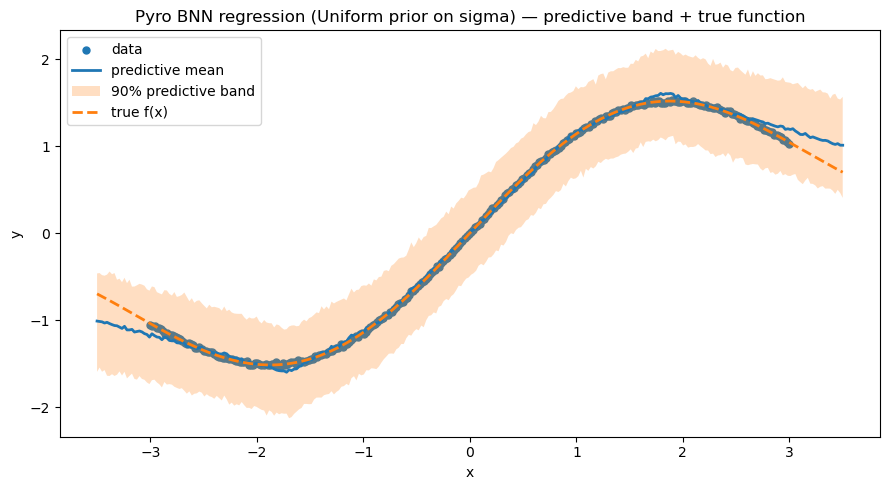

In [2]:
# ----------------------------
# 8) Plot
# ----------------------------
true_f_grid = torch.sin(x_grid.squeeze(-1)) + 0.3 * x_grid.squeeze(-1)
#true_f_grid = 0.3 * x_grid.squeeze(-1)

plt.figure(figsize=(9, 5))
plt.scatter(x.squeeze(-1).numpy(), y.numpy(), s=25, label="data")
plt.plot(x_grid.squeeze(-1).numpy(), y_mean.numpy(), linewidth=2, label="predictive mean")
plt.fill_between(
    x_grid.squeeze(-1).numpy(),
    lower.numpy(),
    upper.numpy(),
    alpha=0.25,
    label="90% predictive band"
)

# add true function
plt.plot(
    x_grid.squeeze(-1).numpy(),
    true_f_grid.numpy(),
    linewidth=2,
    linestyle="--",
    label="true f(x)"
)

plt.title("Pyro BNN regression (Uniform prior on sigma) — predictive band + true function")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()